In [2]:
import os
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycocotools.coco import COCO
from tqdm import tqdm
import math
import torch

In [10]:
def load_coco(json_path):
    """
    Load COCO annotations from the given JSON file path.
    """
    print(f"Loading COCO annotations from: {json_path}")
    coco = COCO(json_path)
    return coco


def extract_mask_stats_with_background(coco):
    """
    Extracts statistics per semantic class (including background) from COCO-formatted segmentation annotations.
    Returns:
        normalized_class_pixel_counts: dict {cat_id: pixel_count / total_pixels_over_all_images}
        relative_area_percent: dict {cat_id: [percent area per image]}
        absolute_area_pixels: dict {cat_id: [pixel count per image/annotation]}
    """
    # Map image_id → image info
    img_id_to_info = {img['id']: img for img in coco.dataset['images']}
    # Map image_id → list of its annotations
    img_id_to_anns = defaultdict(list)
    for ann in coco.dataset['annotations']:
        img_id_to_anns[ann['image_id']].append(ann)

    class_pixel_counts = defaultdict(int)
    relative_area_percent = defaultdict(list)
    absolute_area_pixels = defaultdict(list)
    image_widths=[]
    image_heights=[]
    image_aspectratio=[]

    # We'll treat background as cat_id = 0
    BACKGROUND_ID = 0

    for img_id, image_info in tqdm(img_id_to_info.items(), desc="Processing images"):
        width, height = image_info['width'], image_info['height']
        img_area = width * height
        image_widths.append(width)
        image_heights.append(height)
        image_aspectratio.append(width/height)

        # Build a union mask of all annotations in this image
        union_mask = np.zeros((height, width), dtype=np.uint8)

        # process each annotation
        for ann in img_id_to_anns.get(img_id, []):
            cat_id = ann['category_id']
            mask = coco.annToMask(ann)  # binary mask H×W
            mask_area = mask.sum()

            # accumulate per-class stats
            class_pixel_counts[cat_id] += mask_area
            relative_area_percent[cat_id].append((mask_area / img_area) * 100)
            absolute_area_pixels[cat_id].append(int(mask_area))

            # add to union mask
            union_mask = np.logical_or(union_mask, mask)

        # Now: compute background = those pixels not covered by any annotation
        bg_area = img_area - union_mask.sum()
        class_pixel_counts[BACKGROUND_ID] += bg_area
        relative_area_percent[BACKGROUND_ID].append((bg_area / img_area) * 100)
        absolute_area_pixels[BACKGROUND_ID].append(int(bg_area))

    # Normalize counts to fractions of the total annotated+background area
    total_pixels = sum(class_pixel_counts.values())
    normalized_class_pixel_counts = {
        cat_id: count / total_pixels
        for cat_id, count in class_pixel_counts.items()
    }

    return normalized_class_pixel_counts, relative_area_percent, absolute_area_pixels, image_widths, image_heights, image_aspectratio, class_pixel_counts


def plot_class_distribution(class_pixel_counts, cat_id_to_name):
    """
    Plot total mask pixel distribution per class.
    """
    class_names = [cat_id_to_name[cid] for cid in class_pixel_counts.keys()]
    pixels = [class_pixel_counts[cid] for cid in class_pixel_counts.keys()]
    plt.figure(figsize=(10, 5))
    sns.barplot(x=class_names, y=pixels)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Total Mask Pixels")
    plt.title("Semantic Class Distribution")
    plt.tight_layout()
    plt.show()


def plot_box(data_dict, cat_id_to_name, ylabel, title):
    """
    Generic function to create a box plot from a dictionary of lists keyed by class ID.
    """
    data = []
    labels = []
    for cid, values in data_dict.items():
        data.append(values)
        labels.append(cat_id_to_name[cid])

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data)
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def compute_plain_inverse_class_weights(normalized_class_pixel_counts):
    raw_weights = {k: 1 / v for k, v in normalized_class_pixel_counts.items()}
    max_w = max(raw_weights.values())
    class_weights = {k: w / max_w for k, w in raw_weights.items()}
    return torch.tensor([class_weights.get(i, 0) for i in range(len(class_weights))], dtype=torch.float32)

def compute_median_balancing_class_weights(normalized_class_pixel_counts):
    all_freqs = np.array(list(normalized_class_pixel_counts.values()))
    median = np.median(all_freqs)
    median_weights = {k: median / v for k, v in normalized_class_pixel_counts.items()}
    return torch.tensor([median_weights.get(i, 0) for i in range(len(median_weights))], dtype=torch.float32)

def compute_ens_weights(raw_class_counts, num_classes, beta=0.999):
    """
    Correctly computes Class-Balanced (Effective Number of Samples) weights.

    Args:
        raw_class_counts: dict of total pixel counts per class (including 0).
        num_classes: Total number of possible classes.
        beta: Hyperparameter for effective number calculation (0 <= beta < 1).

    Returns:
        torch.Tensor: Tensor of weights of shape (num_classes,), indexed by class ID.
    """
    # Get raw counts as a tensor in the correct order (0, 1, ...)
    counts_tensor = torch.tensor([raw_class_counts.get(i, 0) for i in range(num_classes)], dtype=torch.float32)

    # Ensure counts are positive for calculation
    Nc = counts_tensor # Use raw counts directly as N_c
    # Handle classes with 0 raw count - effective number approaches 1/(1-beta)
    # The formula itself naturally handles Nc=0 IF beta < 1
    # beta^0 = 1, so (1 - 1) / (1 - beta) = 0. Wait, effective_num is (1-beta^Nc)/(1-beta).
    # As Nc -> 0, beta^Nc -> 1, (1-beta^Nc) -> 0. Effective num -> 0/ (1-beta) = 0. This is wrong.
    # Re-checking standard implementations: the paper formula is correct, effective_num should be > 0 if Nc > 0.
    # If Nc = 0, beta^0 = 1, (1-1)/(1-beta) = 0. Ah, effective_num is only >=1 when Nc >=1.
    # Let's use the formula directly and handle the division by zero for weights.

    # Effective Number of Samples formula using raw counts
    # Add epsilon to handle the denominator (1-beta) if beta=1, though beta < 1 is expected
    epsilon = 1e-6
    effective_num = (1.0 - torch.pow(beta, Nc)) / (1.0 - beta + epsilon)

    # Weights are inversely proportional to effective number
    # Handle division by zero if effective_num is 0 (which happens when Nc=0)
    weights = 1.0 / (effective_num + epsilon) # Add epsilon here too

    # Normalize weights (optional but recommended) - standard is sum to num_classes or max to 1
    # Sum to num_classes:
    # norm_factor = num_classes / weights.sum()
    # weights = weights * norm_factor

    # Max to 1:
    if weights.max() > 0: # Prevent division by zero if all weights are 0 (shouldn't happen with epsilon)
        weights = weights / weights.max()

    return weights

def compute_log_inverse_weights(raw_class_counts, num_classes, log_base=10):
    """
    Correctly computes Logarithmic Inverse Frequency weights based on raw counts.

    Args:
        raw_class_counts: dict of total pixel counts per class (including 0).
        num_classes: Total number of possible classes.
        log_base: Base for the logarithm.

    Returns:
        torch.Tensor: Tensor of weights of shape (num_classes,), indexed by class ID.
    """
    # Get raw counts as a tensor in the correct order (0, 1, ...)
    counts_tensor = torch.tensor([raw_class_counts.get(i, 0) for i in range(num_classes)], dtype=torch.float32)

    # Add a small constant before taking log to handle zero counts
    # log(count + k). Higher count -> higher log -> lower inverse log.
    # Weights should be higher for lower counts.
    # A common form: W_c = 1 / log(Nc + k)
    k = 1.0 # Example smoothing constant, tune this

    # Calculate log inverse weights
    # Handle log(0) case by adding k
    log_weights = 1.0 / (torch.log(counts_tensor + k) / math.log(log_base) + 1e-6) # Use log_base, add epsilon

    # Normalize weights (optional but recommended)
    if log_weights.sum() > 0: # Prevent division by zero
         log_weights = log_weights / log_weights.sum() * num_classes

    return log_weights

def plot_image_size_histograms(widths, heights, aspectratios, bins=30):
    """
    Plots histograms of image widths and heights.
    """
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(widths, bins=bins, kde=True, color="skyblue")
    plt.title("Image Width Distribution")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Frequency")

    plt.subplot(1, 3, 2)
    sns.histplot(heights, bins=bins, kde=True, color="salmon")
    plt.title("Image Height Distribution")
    plt.xlabel("Height (pixels)")
    plt.ylabel("Frequency")

    plt.subplot(1, 3, 3)
    sns.histplot(aspectratios, bins=bins, kde=True, color="salmon")
    plt.title("Image aspect ratio Distribution")
    plt.xlabel("Aspect ratios")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

def analyze_and_plot_coco_segmentation(json_path):
    """
    Master function to load COCO data, extract stats, and plot all three visualizations.
    """
    coco = load_coco(json_path)
    normalized_class_pixel_counts, relative_area_percent, absolute_area_pixels, image_widths, image_heights, image_aspectratio, class_pixel_counts = extract_mask_stats_with_background(coco)
    print(f"Class dist:{normalized_class_pixel_counts}")
    print(f"Plain Class weights:{compute_plain_inverse_class_weights(normalized_class_pixel_counts)} \n  median weight: {compute_median_balancing_class_weights(normalized_class_pixel_counts)}")
    print(f"\n Simple log-inv freq normalized weights:{compute_log_inverse_weights(class_pixel_counts,len(class_pixel_counts))} \n Effective sample weights:{compute_ens_weights(class_pixel_counts,len(class_pixel_counts))}")
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco.loadCats(coco.getCatIds())}
    cat_id_to_name[0]='Background'

    # Plot 1: Total pixel distribution per class
    plot_class_distribution(class_pixel_counts, cat_id_to_name)

    plot_image_size_histograms(image_widths,image_heights,image_aspectratio)

    # Plot 2: Box plot of relative mask area (% of image)
    plot_box(relative_area_percent, cat_id_to_name,
             ylabel="Mask Area (% of Image Area)",
             title="Relative Mask Area Distribution (Per Image)")

    # Plot 3: Box plot of absolute mask pixel counts
    plot_box(absolute_area_pixels, cat_id_to_name,
             ylabel="Mask Area (Pixels)",
             title="Absolute Mask Area Distribution (Per Image)")

### Car parts dataset

Loading COCO annotations from: /home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/Car_parts_dataset/split_annotations/train.json
loading annotations into memory...
Done (t=0.39s)
creating index...
index created!


Processing images: 100%|██████████| 798/798 [00:16<00:00, 48.33it/s]


Class dist:{4: 0.013598811227524385, 17: 0.003289948604559128, 7: 0.028755398538218086, 2: 0.02753507376426069, 14: 0.02029575561332178, 10: 0.004556770240681306, 1: 0.0484224017664052, 11: 0.007274632182462512, 6: 0.03495594445796423, 16: 0.02861226672876874, 3: 0.00987005314309831, 9: 0.01443535952478179, 12: 0.013973821557145867, 8: 0.06861302516570666, 13: 0.04619464389903683, 5: 0.06428179693977044, 15: 0.006362726119743036, 0: 0.48061029177349546, 18: 0.007983718239161466, 19: 0.033157377929045176, 21: 0.012211505281666786, 20: 0.025008677303182125}
Plain Class weights:{4: 0.24192913259213258, 17: 1.0, 7: 0.11441151129192452, 2: 0.11948210608497938, 14: 0.16210032615881828, 10: 0.7219913295578473, 1: 0.06794269768835896, 11: 0.4522494776423814, 6: 0.0941169994281061, 16: 0.11498385065910166, 3: 0.33332633136424833, 9: 0.2279090173619254, 12: 0.23543656909492516, 8: 0.04794933027094497, 13: 0.07121926541418201, 5: 0.05118009702873867, 15: 0.5170658838120782, 0: 0.00684535612506115

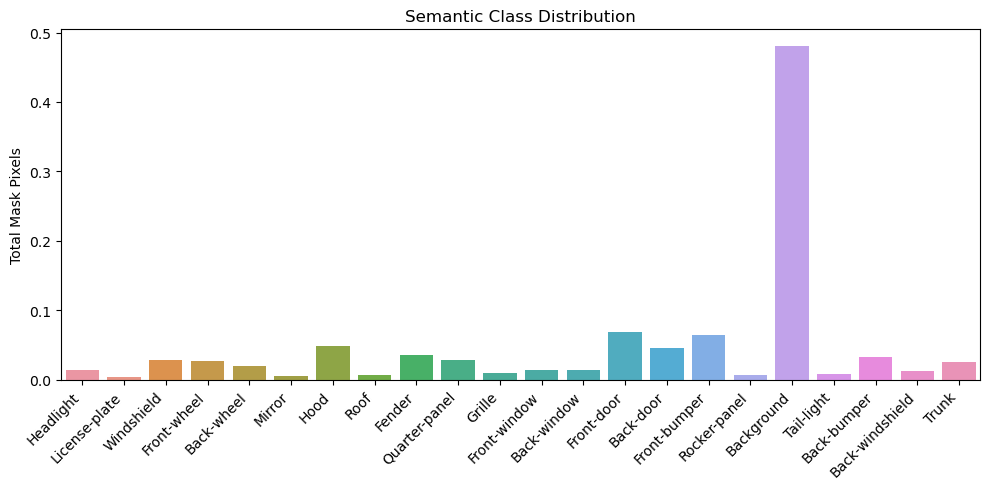

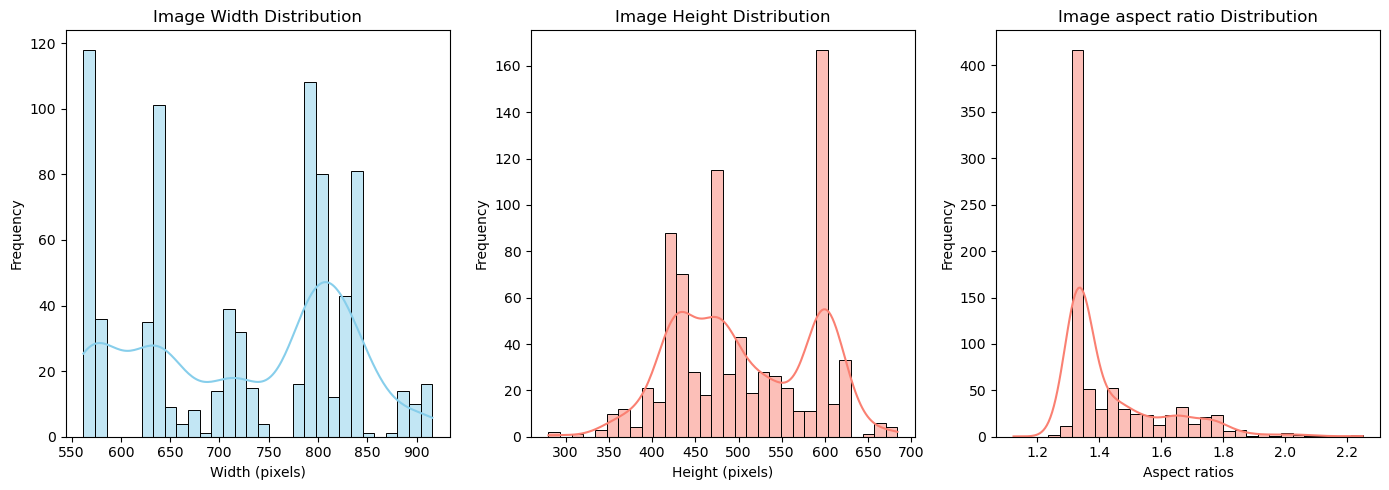

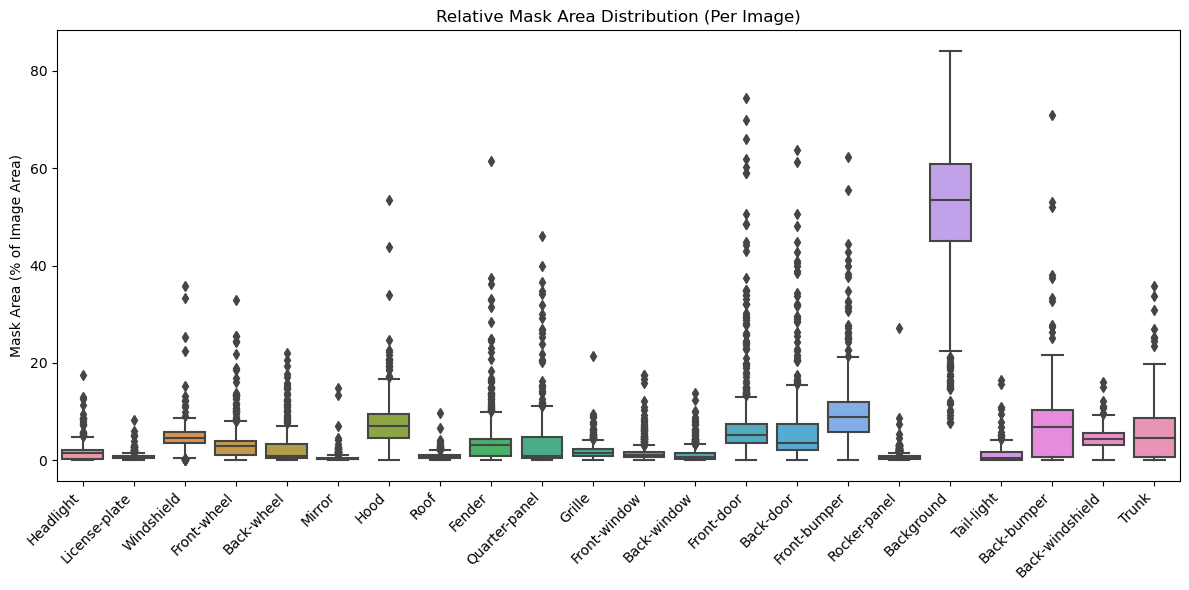

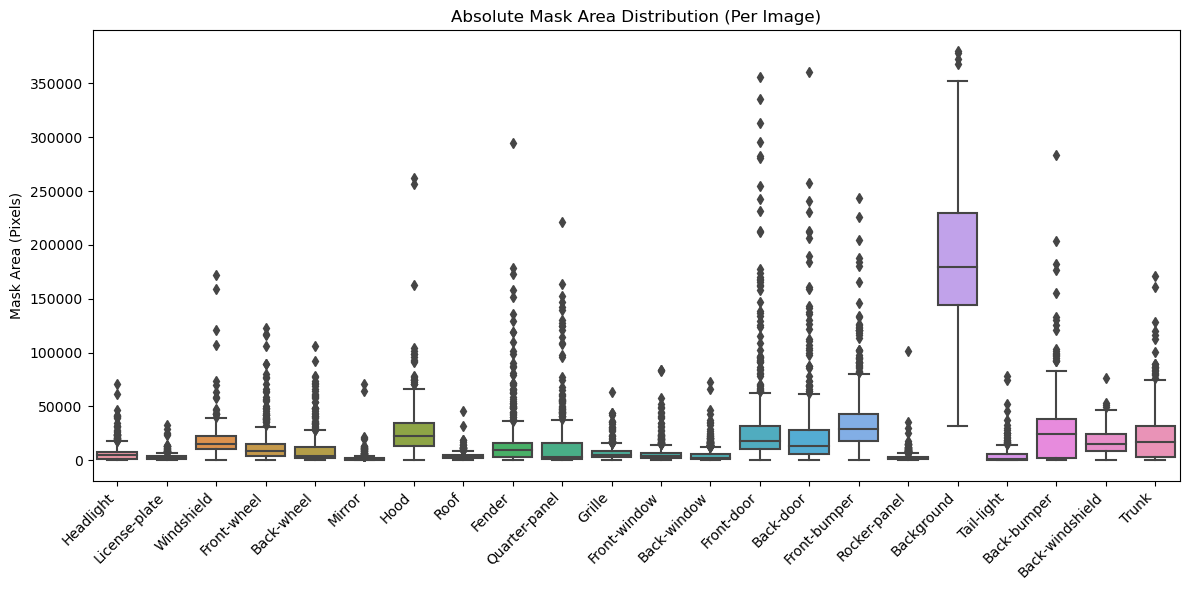

In [18]:
analyze_and_plot_coco_segmentation("/home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/Car_parts_dataset/split_annotations/train.json")

### Car damages dataset

Loading COCO annotations from: /home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/Car_damages_dataset/split_annotations/train.json
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


Processing images: 100%|██████████| 651/651 [00:09<00:00, 69.71it/s]


Class dist:{1: 0.023458578160110023, 2: 0.04824627946138216, 0: 0.9066975453829725, 6: 0.006646892971946589, 3: 0.0076661689659696, 4: 0.001274962652628073, 5: 0.0006430418383717922, 7: 0.001362473000410685, 8: 0.004004057566208577}
Plain Class weights:{1: 0.027411799384552998, 2: 0.01332831972849851, 0: 0.0007092131677716003, 6: 0.09674322139468314, 3: 0.08388046770509208, 4: 0.5043613136794979, 5: 1.0, 7: 0.47196666515810776, 8: 0.16059755079412746} 
  Inverse weight: {1: 0.28334594392635665, 2: 0.13777006322875054, 0: 0.007330882283506196, 6: 1.0, 3: 0.8670423260239092, 4: 5.213402101030479, 5: 10.336641529852535, 7: 4.878550231779302, 8: 1.6600393131311797}


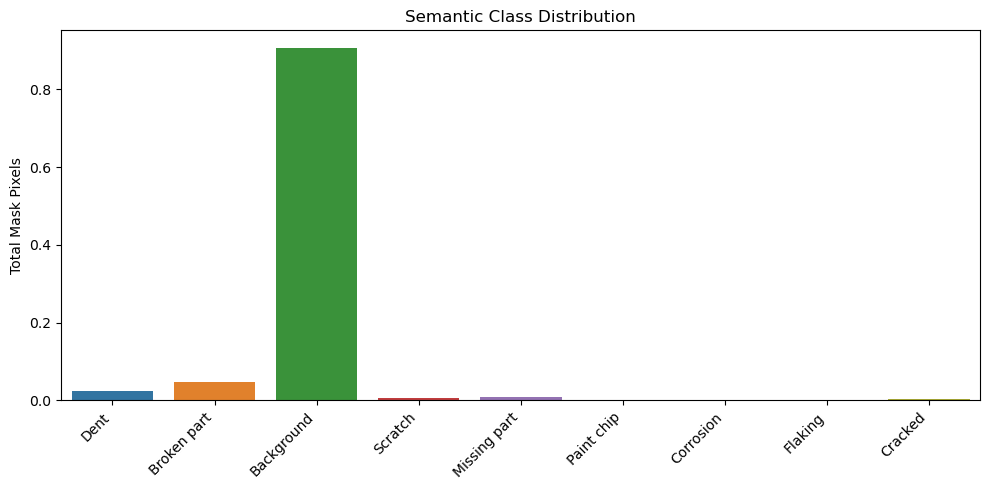

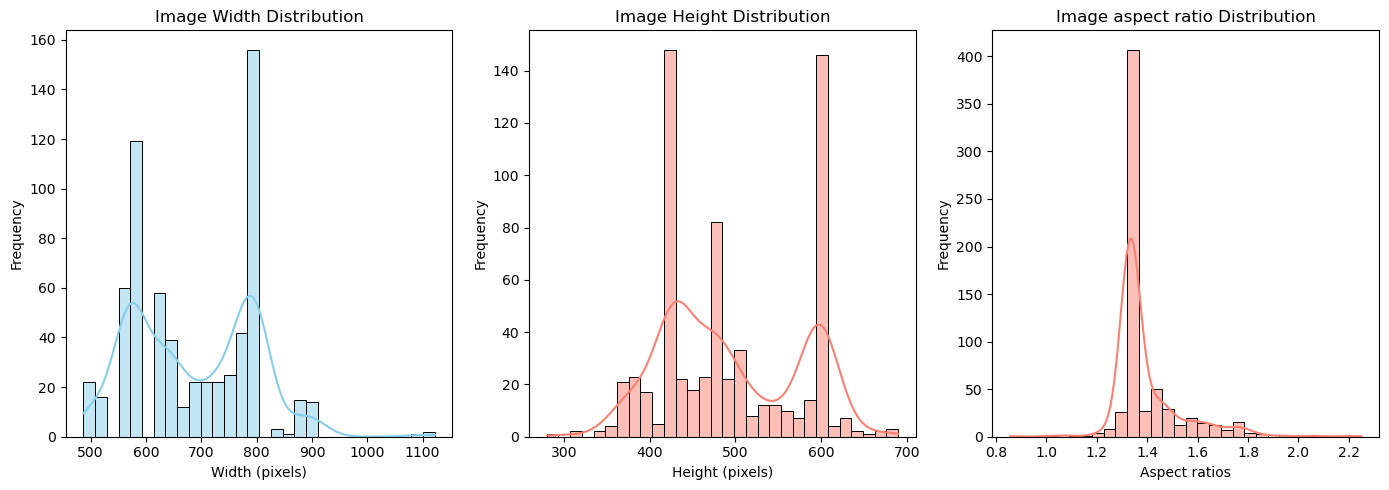

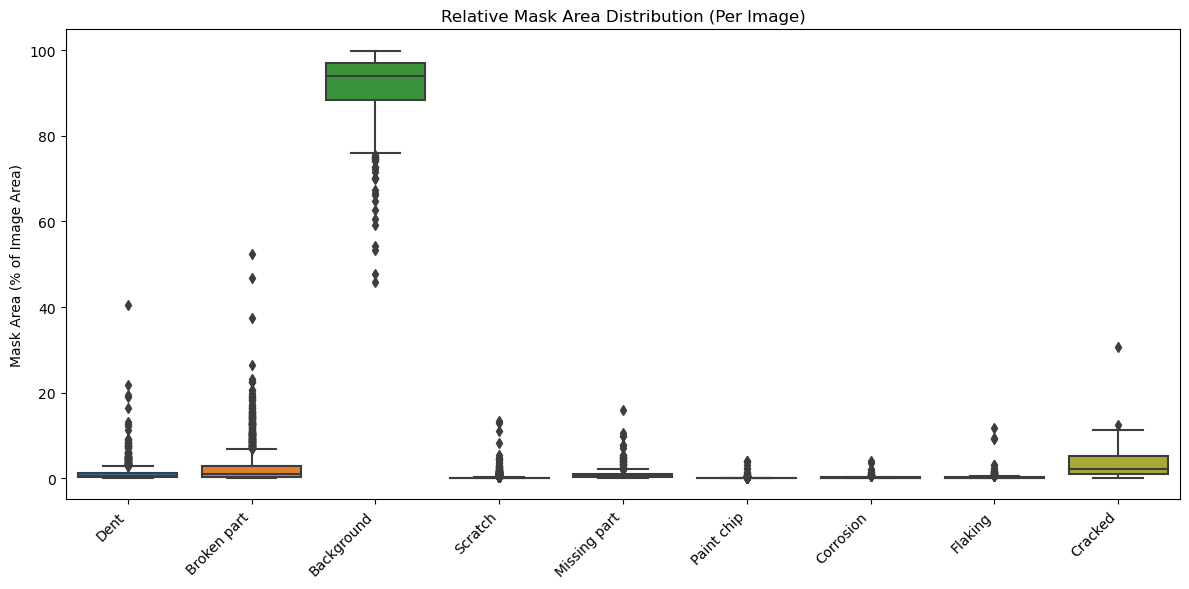

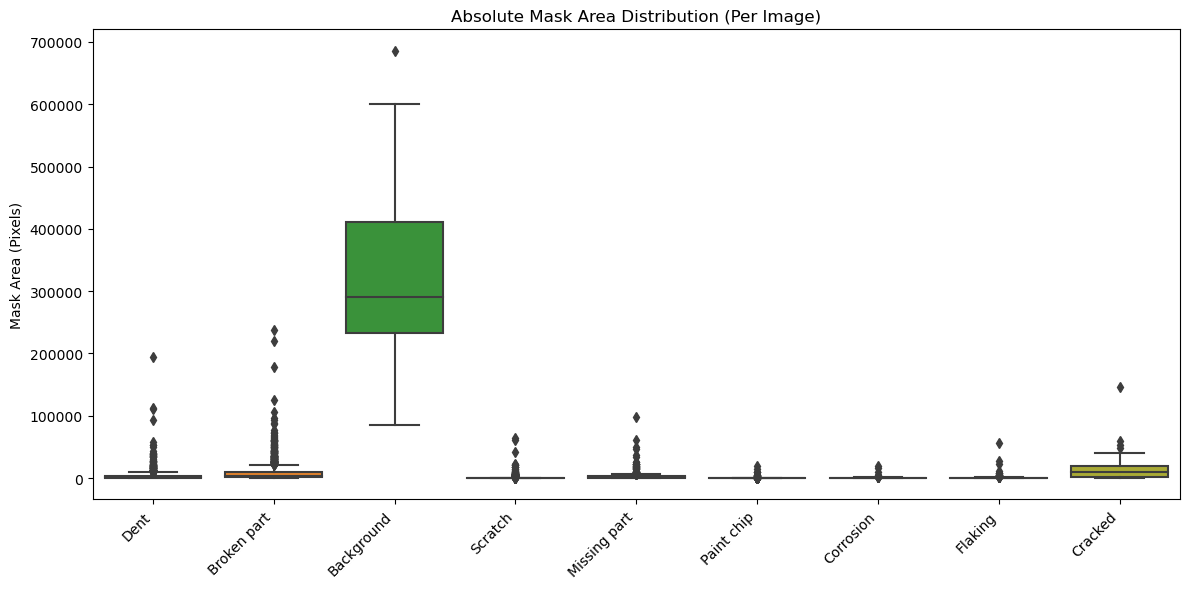

In [19]:
analyze_and_plot_coco_segmentation("/home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/Car_damages_dataset/split_annotations/train.json")

### CarDD dataset

Loading COCO annotations from: /home/akshay/dgx-code/ImageSegmentation/data/CarDD_release/CarDD_COCO/split_annotations/train.json
loading annotations into memory...
Done (t=0.22s)
creating index...
index created!


Processing images: 100%|██████████| 2816/2816 [00:17<00:00, 165.21it/s]


Class dist:{2: 0.054921060371781724, 6: 0.023567537989071845, 0: 0.7466343165889466, 3: 0.0013865019590125105, 1: 0.055351661169645086, 5: 0.0301741895722353, 4: 0.08796473234930693}
Plain Class weights:{2: 0.025245360334027547, 6: 0.058831005582994075, 0: 0.0018570027230289201, 3: 1.0, 1: 0.025048967451276237, 5: 0.04594993200043711, 4: 0.015762021005267513} 
  Inverse weight: {2: 1.0, 6: 2.3303690184884123, 0: 0.0735581785507698, 3: 39.61123892742092, 1: 0.9922206345976929, 5: 1.8201337351680587, 4: 0.6243531800186787}


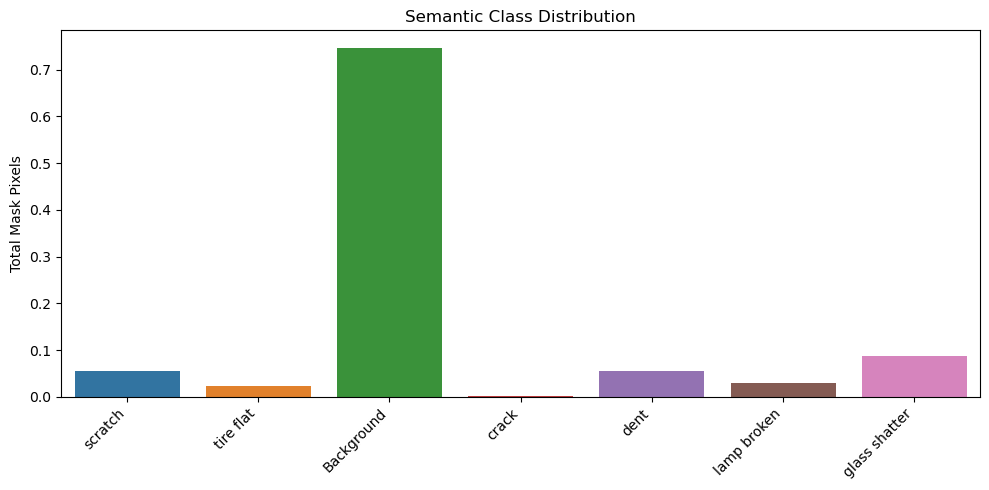

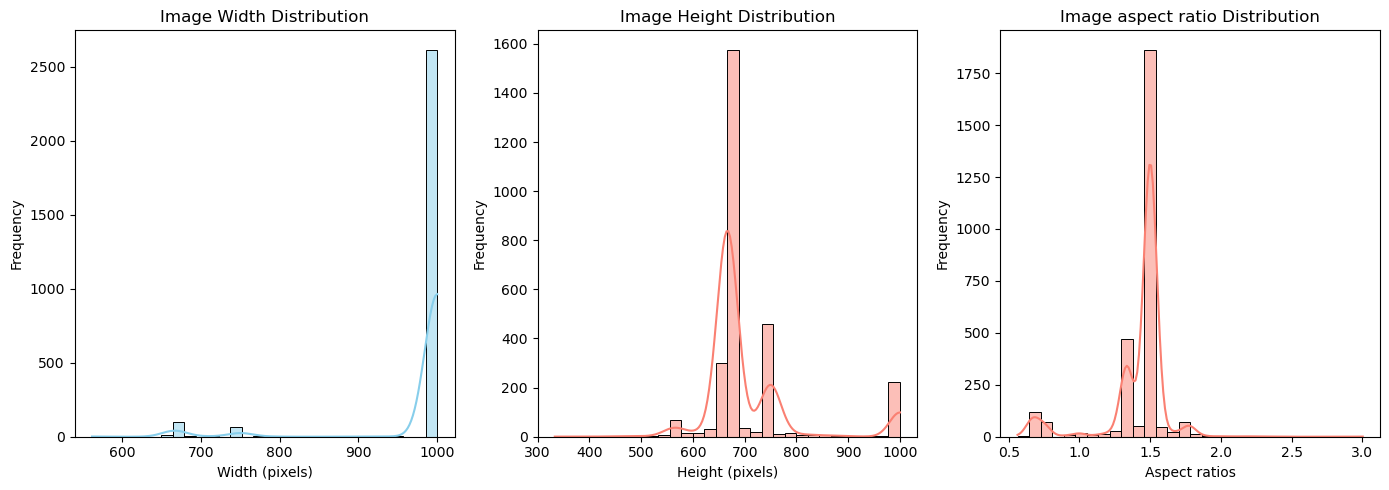

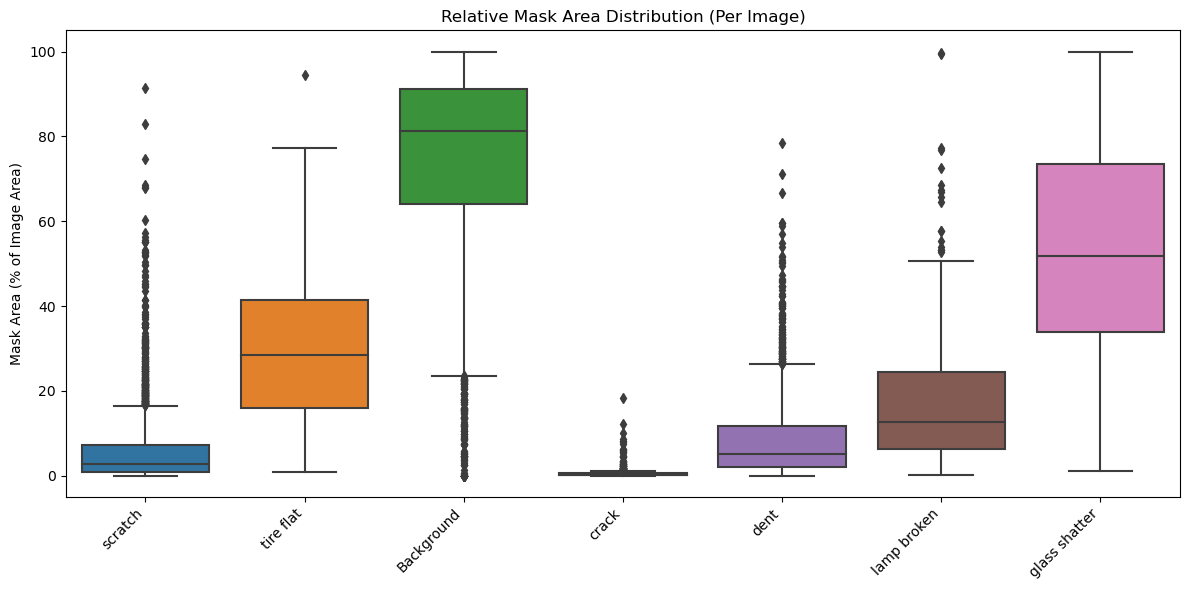

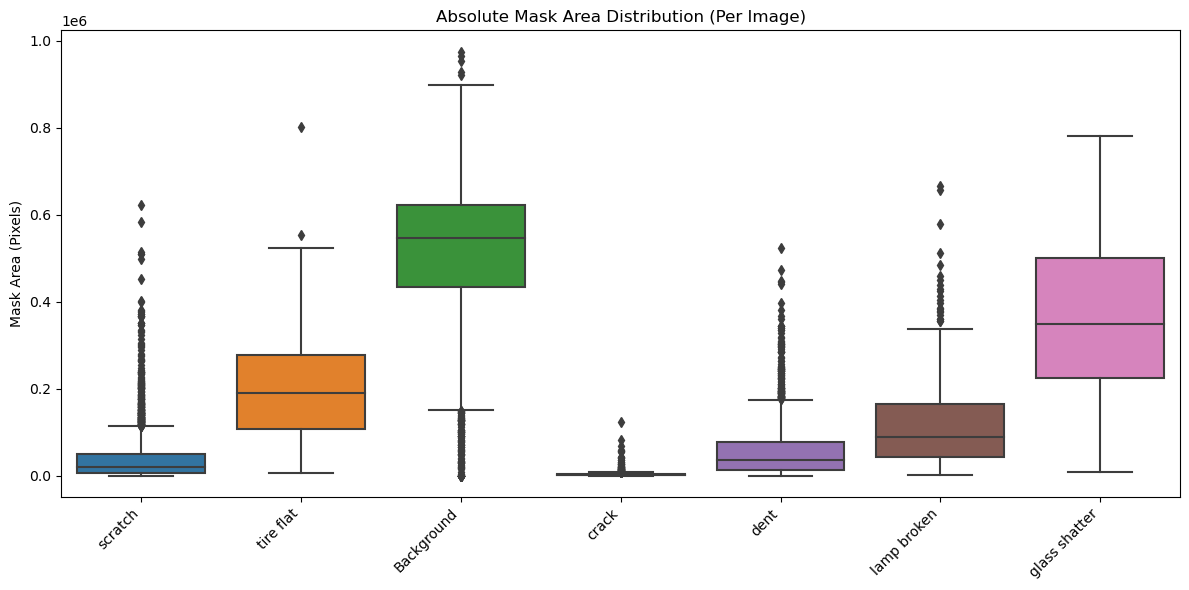

In [20]:
analyze_and_plot_coco_segmentation("/home/akshay/dgx-code/ImageSegmentation/data/CarDD_release/CarDD_COCO/split_annotations/train.json")

Loading COCO annotations from: /home/akshay/dgx-code/ImageSegmentation/data/CarDD_release/CarDD_COCO/split_annotations/train.json
loading annotations into memory...
Done (t=0.34s)
creating index...
index created!


Processing annotations: 100%|██████████| 6211/6211 [00:09<00:00, 627.71it/s]


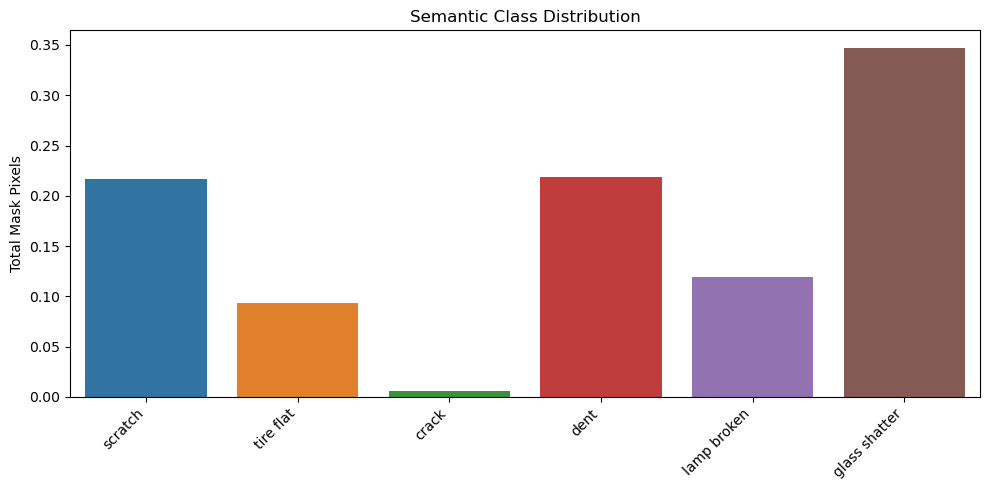

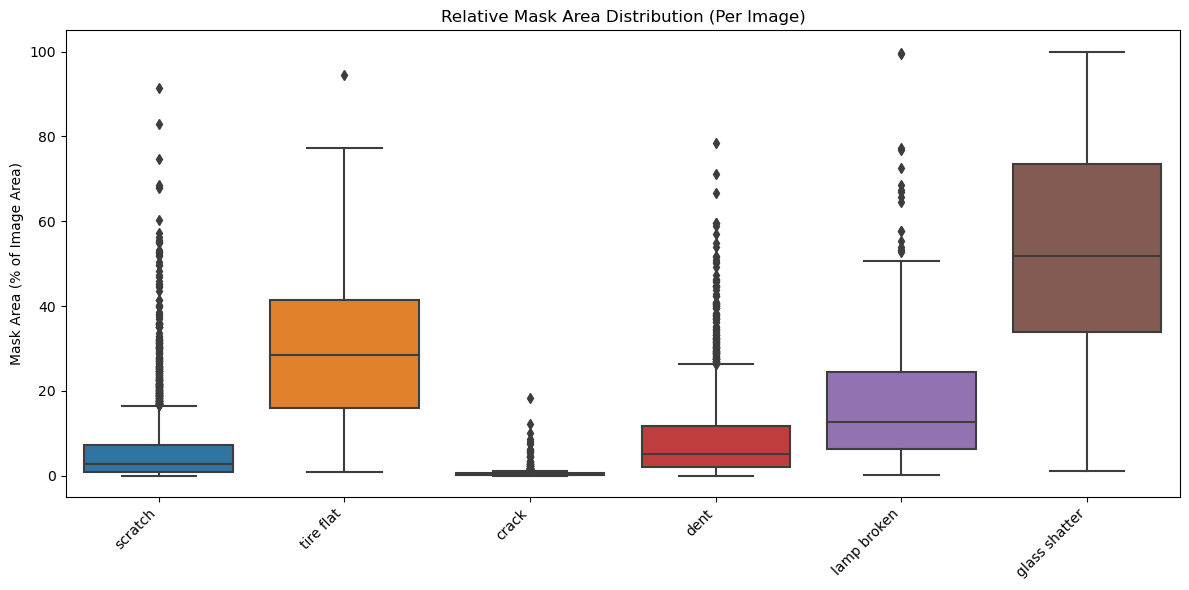

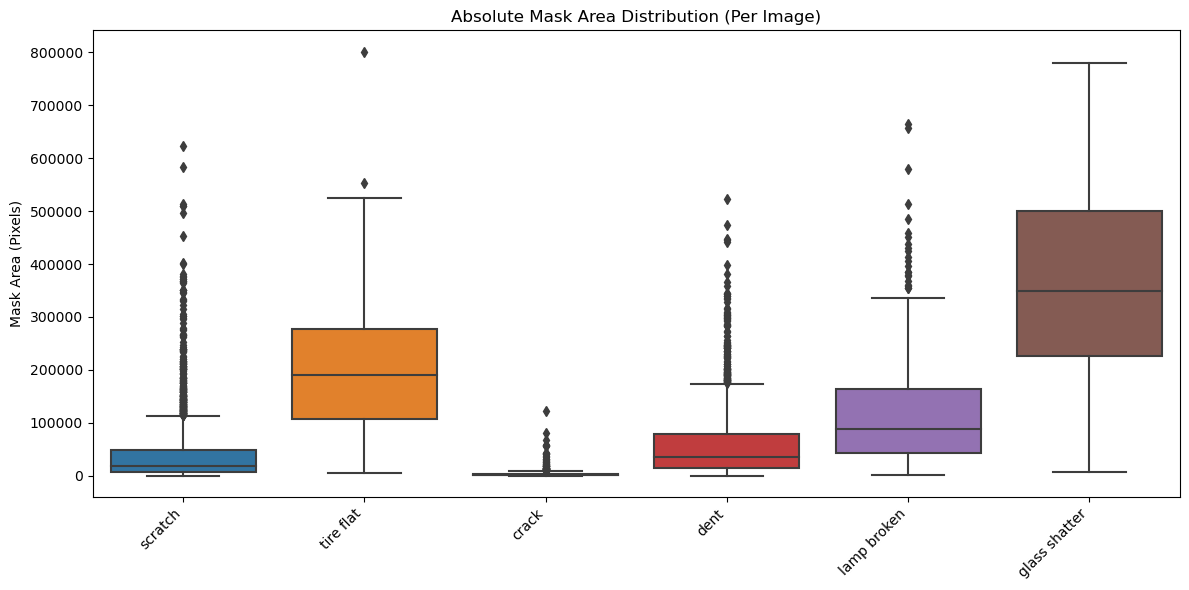

In [7]:
analyze_and_plot_coco_segmentation("/home/akshay/dgx-code/ImageSegmentation/data/CarDD_release/CarDD_COCO/split_annotations/train.json")

### Merged damage dataset

Loading COCO annotations from: /home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/CarDNN_Kaggle_merged_Car_damages_dataset/split_annotations/train.json
loading annotations into memory...
Done (t=0.39s)
creating index...
index created!


Processing images: 100%|██████████| 3467/3467 [00:29<00:00, 118.36it/s]


Class dist:{1: 0.051989985239640796, 2: 0.13185533203639416, 0: 0.763505708525398, 6: 0.04983274368127845, 3: 0.0008080490581779473, 4: 0.00013438685936109813, 5: 6.777953292862539e-05, 7: 0.0001436108478252789, 8: 0.0016624042189955933}
Plain Class weights:tensor([8.8774e-05, 1.3037e-03, 5.1404e-04, 8.3880e-02, 5.0436e-01, 1.0000e+00,
        1.3601e-03, 4.7197e-01, 4.0772e-02]) 
  median weight: tensor([2.1773e-03, 3.1975e-02, 1.2608e-02, 2.0573e+00, 1.2370e+01, 2.4527e+01,
        3.3360e-02, 1.1576e+01, 1.0000e+00])

 Simple log-inv freq normalized weights:tensor([0.7249, 0.8299, 0.7903, 1.0704, 1.2231, 1.2935, 0.8318, 1.2167, 1.0193]) 
 Effective sample weights:tensor([1., 1., 1., 1., 1., 1., 1., 1., 1.])


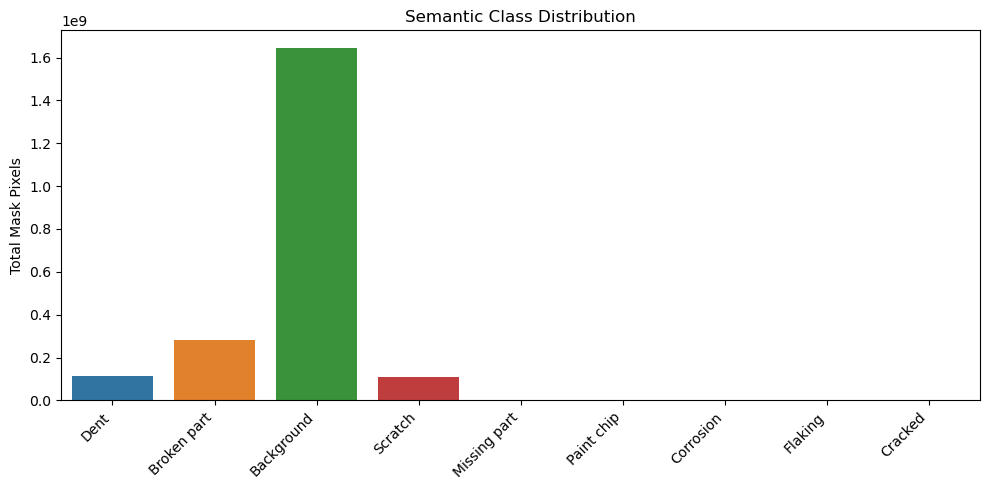

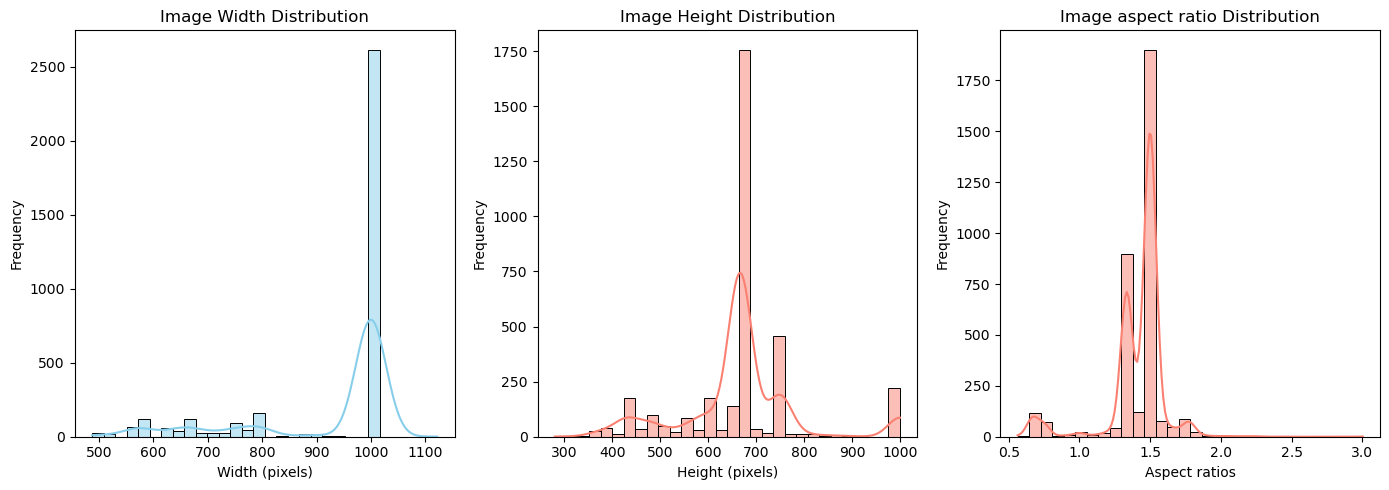

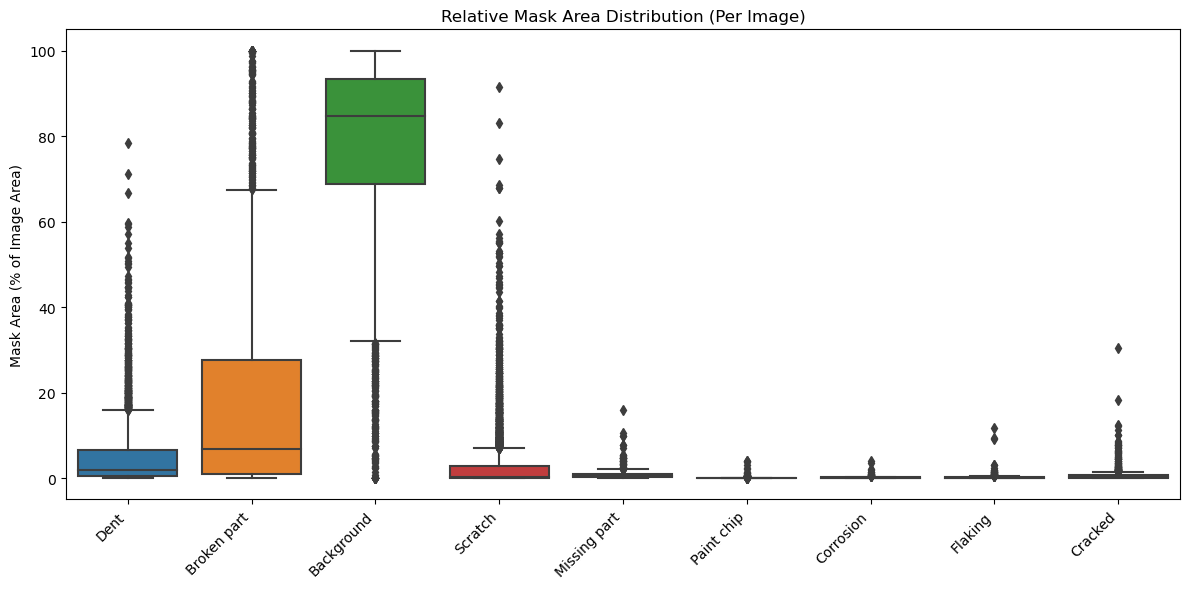

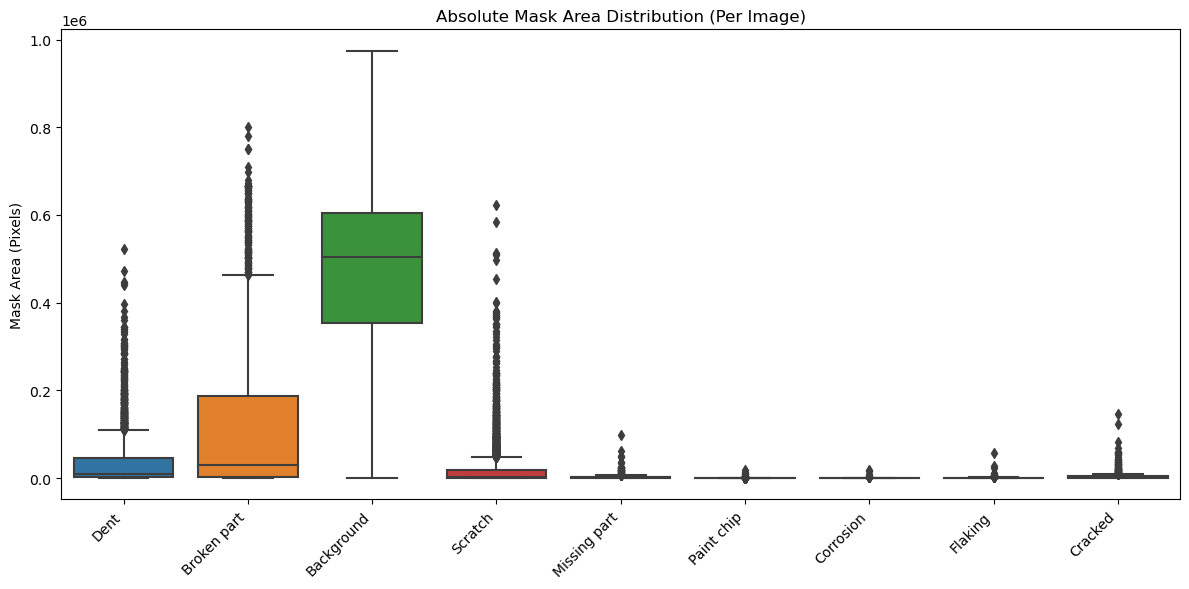

: 

In [ ]:
analyze_and_plot_coco_segmentation("/home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/CarDNN_Kaggle_merged_Car_damages_dataset/split_annotations/train.json")

Loading COCO annotations from: /home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/CarDNN_Kaggle_merged_Car_damages_dataset/split_annotations/train.json
loading annotations into memory...
Done (t=0.32s)
creating index...
index created!


Processing annotations: 100%|██████████| 13529/13529 [00:15<00:00, 854.73it/s]


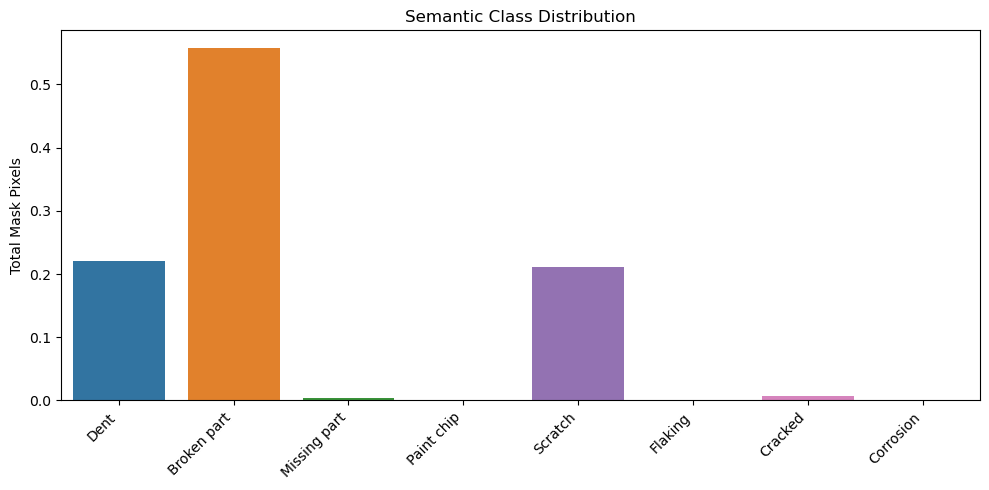

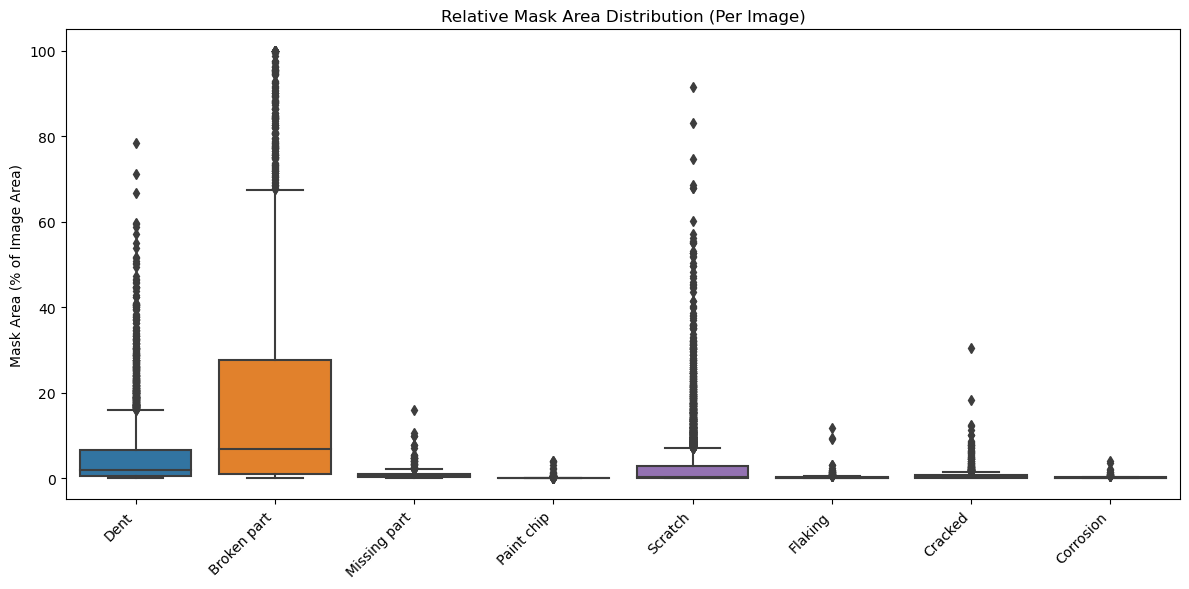

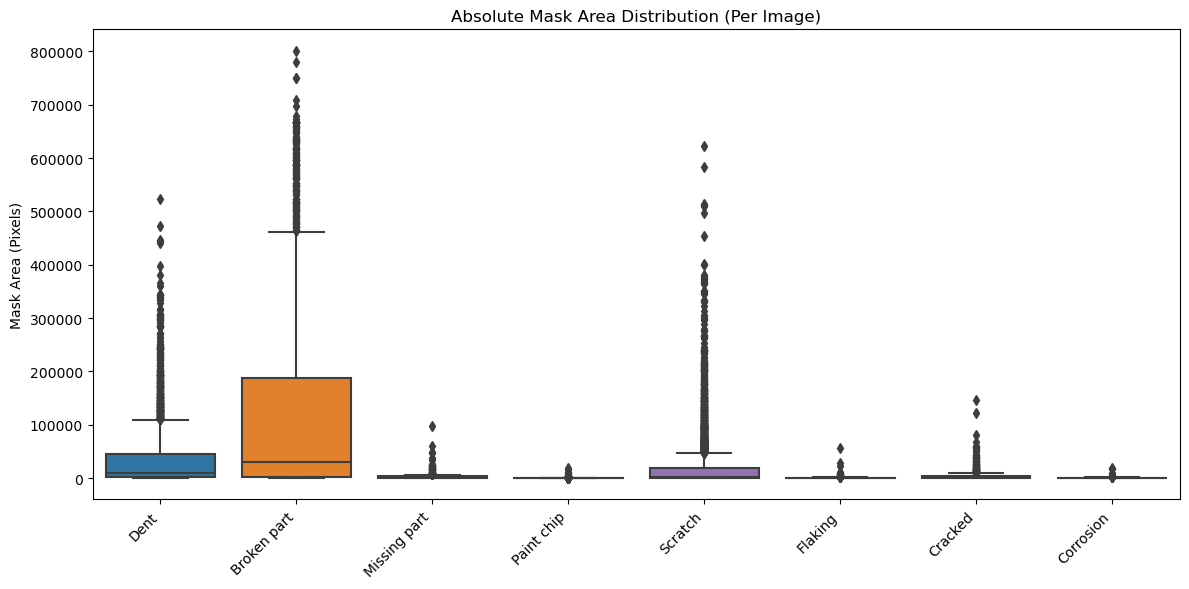

: 

In [ ]:
analyze_and_plot_coco_segmentation("/home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/CarDNN_Kaggle_merged_Car_damages_dataset/split_annotations/train.json")